In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder

In [3]:
# Load dataset
df = sns.load_dataset('iris')  # Use pd.read_csv('iris.csv') if you have the file
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:

# Encode species column to numbers
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])  # Converts to 0, 1, 2

In [5]:
# Separate features and labels
X = df.drop('species', axis=1)
y = df['species']

In [6]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state=42)

In [7]:
# Train the model
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [8]:
# Make predictions
y_pred = model.predict(X_test)

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]


In [10]:
# Overall Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
error_rate = 1 - accuracy

In [11]:

print(f"\nOverall Accuracy: {accuracy:.2f}")
print(f"Overall Error Rate: {error_rate:.2f}")
print(f"Overall Precision: {precision:.2f}")
print(f"Overall Recall: {recall:.2f}")


Overall Accuracy: 1.00
Overall Error Rate: 0.00
Overall Precision: 1.00
Overall Recall: 1.00


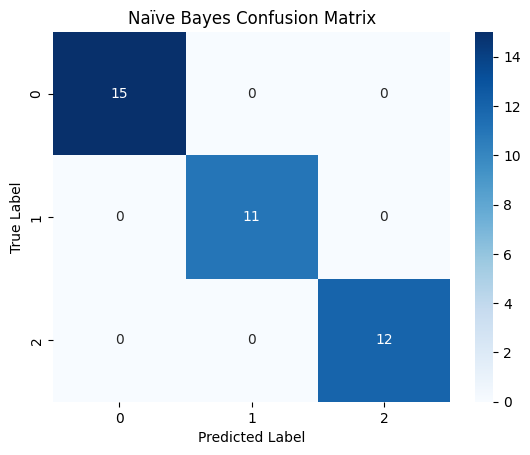

In [12]:
# Heatmap of Confusion Matrix
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Naïve Bayes Confusion Matrix")
plt.show()